<a href="https://colab.research.google.com/github/profpius/customer-churn-prediction/blob/main/churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction
### Binary Classification using Logistic Regression, Random Forest & XGBoost
---
**Dataset:** ~37,000 customer records  
**Target:** `churn_risk_score` where 1 = Churned, 0 = Stayed  
**Goal:** Predict which customers are likely to churn, identify key churn drivers, and deliver a production-ready model pipeline.

**Methodology Highlights:**
- Full `sklearn` Pipeline to prevent data leakage
- Stratified K-Fold cross-validation for reliable evaluation
- SHAP explainability for business-grade feature insights
- Hyperparameter tuning with `RandomizedSearchCV`
- Model serialisation with `joblib` for deployment readiness
- End-to-end prediction demo on unseen data

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score,
    ConfusionMatrixDisplay
)

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Dataset

**Upload CSV file**

In [13]:
df = pd.read_csv('churn.csv', index_col=0)

print(f'Dataset Shape: {df.shape}')
print(f'\nColumns:\n{df.columns.tolist()}')
df.head()

Dataset Shape: (36992, 23)

Columns:
['age', 'gender', 'security_no', 'region_category', 'membership_category', 'joining_date', 'joined_through_referral', 'referral_id', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'last_visit_time', 'days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount', 'offer_application_preference', 'past_complaint', 'complaint_status', 'feedback', 'churn_risk_score']


,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,18,F,XW0DQ7H,Village,Platinum Membership,2017-08-17,No,xxxxxxxx,Gift Vouchers/Coupons,?,...,300.63,53005.25,17.0,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,32,F,5K0N3X1,City,Premium Membership,2017-08-28,?,CID21329,Gift Vouchers/Coupons,Desktop,...,306.34,12838.38,10.0,NaN,Yes,No,Yes,Solved,Quality Customer Care,0
2,44,F,1F2TCL3,Town,No Membership,2016-11-11,Yes,CID12313,Gift Vouchers/Coupons,Desktop,...,516.16,21027.00,22.0,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1
3,37,M,VJGJ33N,City,No Membership,2016-10-29,Yes,CID3793,Gift Vouchers/Coupons,Desktop,...,53.27,25239.56,6.0,567.66,No,Yes,Yes,Unsolved,Poor Website,1
4,31,F,SVZXCWB,City,No Membership,2017-09-12,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,...,113.13,24483.66,16.0,663.06,No,Yes,Yes,Solved,Poor Website,1


In [14]:
print('Target Variable Distribution:')
print(df['churn_risk_score'].value_counts())
print(f'\nChurn Rate: {df["churn_risk_score"].mean()*100:.1f}%')

Target Variable Distribution:
churn_risk_score
1    20012
0    16980
Name: count, dtype: int64

Churn Rate: 54.1%


**The dataset is fairly balanced (~50/50), so no need for special resampling techniques like SMOTE.**

In [9]:
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nQuestion marks per column (acting as placeholders for missing data):')
for col in df.columns:
    count = (df[col] == '?').sum()
    if count > 0:
        print(f'  {col}: {count}')

Data Types:
age                               int64
gender                           object
security_no                      object
region_category                  object
membership_category              object
joining_date                     object
joined_through_referral          object
referral_id                      object
preferred_offer_types            object
medium_of_operation              object
internet_option                  object
last_visit_time                  object
days_since_last_login             int64
avg_time_spent                  float64
avg_transaction_value           float64
avg_frequency_login_days         object
points_in_wallet                float64
used_special_discount            object
offer_application_preference     object
past_complaint                   object
complaint_status                 object
feedback                         object
churn_risk_score                  int64
dtype: object

Missing Values:
age                                0


## 3. Data Preprocessing

In [15]:
# Drop identifier and datetime columns that add no predictive value without
# significant feature engineering (out of scope for this project)
drop_cols = ['security_no', 'referral_id', 'joining_date', 'last_visit_time']
df.drop(columns=drop_cols, inplace=True)

# Replace '?' placeholders with NaN so sklearn imputers handle them correctly
df.replace('?', np.nan, inplace=True)

# avg_frequency_login_days was stored as object dtype, so i have to convert to numeric
df['avg_frequency_login_days'] = pd.to_numeric(df['avg_frequency_login_days'], errors='coerce')

print(f'Columns remaining: {df.shape[1]}')
print(f'Missing values after replacement: {df.isnull().sum().sum()}')

Columns remaining: 19
Missing values after replacement: 23512


In [ ]:
# Separate features (X) and target (y) BEFORE any preprocessing
# This is critical because it ensures no target information leaks into the features
y = df['churn_risk_score'].values
X = df.drop(columns=['churn_risk_score'])

# Identify numeric and categorical columns for separate preprocessing
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'Numeric columns  ({len(num_cols)}): {num_cols}')
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Numeric columns  (6): ['age', 'days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet']
Categorical columns (12): ['gender', 'region_category', 'membership_category', 'joined_through_referral', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'used_special_discount', 'offer_application_preference', 'past_complaint', 'complaint_status', 'feedback']


## 4. Train / Test Split

In [18]:
# Stratified split ensures the churn ratio is preserved in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train size : {len(X_train):,}')
print(f'Test size  : {len(X_test):,}')
print(f'Features   : {X.shape[1]}')
print(f'Churn rate in train: {y_train.mean()*100:.1f}%')
print(f'Churn rate in test : {y_test.mean()*100:.1f}%')

Train size : 29,593
Test size  : 7,399
Features   : 18
Churn rate in train: 54.1%
Churn rate in test : 54.1%


## 5. Build Preprocessing Pipelines

We use `sklearn`'s `Pipeline` and `ColumnTransformer` to bundle preprocessing with modelling.

**Why Pipelines?**
- Guarantee that imputers and scalers are *fit only on training data* so it can prevent data leakage
- Make the workflow reproducible and deployment-ready (one `pipeline.predict()` call handles everything)
- Enable proper cross-validation without manual re-fitting preprocessors each fold

In [19]:
# Numeric pipeline: impute missing values with median, then scale
# Median is preferred over mean because it is robust to outliers
numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler',  StandardScaler())])

# Categorical pipeline: impute with most frequent value, then ordinal encode
# OrdinalEncoder is used in a Pipeline so we retain inverse-transform capability
categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])

# Combine both pipelines into a single ColumnTransformer
preprocessor = ColumnTransformer([('num', numeric_pipeline, num_cols), ('cat', categorical_pipeline, cat_cols)])

print('Preprocessing pipelines built.')

Preprocessing pipelines built.


## 6. Model Training

We train three models, each wrapped in a full Pipeline:

- **Logistic Regression** — simple, interpretable baseline
- **Random Forest** — ensemble of decision trees; handles non-linearity without scaling
- **XGBoost** — optimised gradient boosting; industry standard for tabular data

> Note: Tree-based models don't require feature scaling, but the Pipeline handles this automatically since the `StandardScaler` is included in the numeric sub-pipeline. There is no harm in scaling for trees.

In [21]:
model_pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                                random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   XGBClassifier(n_estimators=100, learning_rate=0.1,
                                       use_label_encoder=False, eval_metric='logloss',
                                       random_state=42))
    ]),
}

results = {}
for name, pipeline in model_pipelines.items():
    print(f'Training {name}')
    pipeline.fit(X_train, y_train)
    yp  = pipeline.predict(X_test)
    ypr = pipeline.predict_proba(X_test)[:, 1]
    results[name] = {
        'pipeline' : pipeline,
        'y_pred'   : yp,
        'y_prob'   : ypr,
        'accuracy' : round(accuracy_score(y_test, yp)  * 100, 2),
        'precision': round(precision_score(y_test, yp) * 100, 2),
        'recall'   : round(recall_score(y_test, yp)    * 100, 2),
        'f1'       : round(f1_score(y_test, yp)        * 100, 2),
        'roc_auc'  : round(roc_auc_score(y_test, ypr)  * 100, 2),
    }
    r = results[name]
    print(f'  Accuracy:{r["accuracy"]}% | Precision:{r["precision"]}% | '
          f'Recall:{r["recall"]}% | F1:{r["f1"]}% | ROC-AUC:{r["roc_auc"]}%\n')

Training Logistic Regression
  Accuracy:77.56% | Precision:79.06% | Recall:79.62% | F1:79.34% | ROC-AUC:83.29%

Training Random Forest
  Accuracy:93.16% | Precision:92.91% | Recall:94.58% | F1:93.74% | ROC-AUC:97.55%

Training XGBoost
  Accuracy:93.47% | Precision:93.29% | Recall:94.75% | F1:94.01% | ROC-AUC:97.6%



## 7. Stratified K-Fold Cross-Validation

A single train-test split can produce optimistic or pessimistic results depending on the random seed.
**Stratified K-Fold CV** evaluates each model across 5 different data splits and reports mean ± std deviation, giving a much more reliable and statistically grounded performance estimate.

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print('Running 5-Fold Cross-Validation...\n')
cv_results = {}
for name, pipeline in model_pipelines.items():
    scores = cross_validate(pipeline, X, y, cv=skf, scoring=cv_scoring, n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}:')
    for metric in cv_scoring:
        vals = scores[f'test_{metric}'] * 100
        print(f'  {metric.upper():12}: {vals.mean():.2f}% ± {vals.std():.2f}%')
    print()

Running 5-Fold Cross-Validation...

Logistic Regression:
  ACCURACY    : 76.94% ± 0.39%
  PRECISION   : 78.65% ± 0.36%
  RECALL      : 78.75% ± 0.46%
  F1          : 78.70% ± 0.38%
  ROC_AUC     : 82.47% ± 0.36%

Random Forest:
  ACCURACY    : 93.16% ± 0.47%
  PRECISION   : 92.99% ± 0.45%
  RECALL      : 94.47% ± 0.57%
  F1          : 93.73% ± 0.43%
  ROC_AUC     : 97.44% ± 0.11%

XGBoost:
  ACCURACY    : 93.25% ± 0.33%
  PRECISION   : 93.24% ± 0.35%
  RECALL      : 94.37% ± 0.45%
  F1          : 93.80% ± 0.31%
  ROC_AUC     : 97.55% ± 0.13%



In [23]:
# Build a clean cross-validation summary table
cv_summary_rows = []
for name in model_pipelines:
    row = {'Model': name}
    for metric in cv_scoring:
        vals = cv_results[name][f'test_{metric}'] * 100
        row[f'{metric.upper()} Mean'] = round(vals.mean(), 2)
        row[f'{metric.upper()} Std']  = round(vals.std(),  2)
    cv_summary_rows.append(row)

cv_summary = pd.DataFrame(cv_summary_rows).set_index('Model')
cv_summary

,ACCURACY Mean,ACCURACY Std,PRECISION Mean,PRECISION Std,RECALL Mean,RECALL Std,F1 Mean,F1 Std,ROC_AUC Mean,ROC_AUC Std
Model,,,,,,,,,,
Logistic Regression,76.94,0.39,78.65,0.36,78.75,0.46,78.70,0.38,82.47,0.36
Random Forest,93.16,0.47,92.99,0.45,94.47,0.57,93.73,0.43,97.44,0.11
XGBoost,93.25,0.33,93.24,0.35,94.37,0.45,93.80,0.31,97.55,0.13


## 8. Model Evaluation

In [24]:
# Holdout test-set summary
summary = pd.DataFrame({
    name: {
        'Accuracy (%)' : res['accuracy'],
        'Precision (%)': res['precision'],
        'Recall (%)'   : res['recall'],
        'F1 Score (%)'  : res['f1'],
        'ROC-AUC (%)'  : res['roc_auc'],
    }
    for name, res in results.items()
}).T
summary

,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC-AUC (%)
Logistic Regression,77.56,79.06,79.62,79.34,83.29
Random Forest,93.16,92.91,94.58,93.74,97.55
XGBoost,93.47,93.29,94.75,94.01,97.60


In [25]:
# XGBoost is selected as the best model.
# It achieves the highest F1 Score and ROC-AUC, confirming strong performance
# on both precision and recall simultaneously which the key metrics for churn prediction
# where missing a real churner carries a business cost.
best_name = 'XGBoost'
best_pipeline = results[best_name]['pipeline']
print(f'Best Model: {best_name}')
print(f"F1: {results[best_name]['f1']}% | ROC-AUC: {results[best_name]['roc_auc']}%")

Best Model: XGBoost
F1: 94.01% | ROC-AUC: 97.6%


## 9. Visualizations

In [62]:
# Global plot styling
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#333647',   'axes.labelcolor': '#c8ccd8',
    'xtick.color': '#c8ccd8',      'ytick.color': "#eff1f7",
    'text.color': '#e0e3ed',       'grid.color': '#2a2d3a',
    'grid.alpha': 0.5,             'font.family': 'DejaVu Sans',
    'axes.titlesize': 12,          'axes.labelsize': 10,
})
P = ['#4f8ef7', '#f76f4f', '#4fcfa0', '#f7c94f', '#b07fff']

# Extract feature names after ColumnTransformer to use in importance plots
feat_names = num_cols + cat_cols

# Extract raw classifier and feature importances from best pipeline
rf_clf  = results['Random Forest']['pipeline'].named_steps['classifier']
xgb_clf = results['XGBoost']['pipeline'].named_steps['classifier']
rf_imp  = pd.Series(rf_clf.feature_importances_,  index=feat_names)
xgb_imp = pd.Series(xgb_clf.feature_importances_, index=feat_names)

print('Plotting variables ready.')

Plotting variables ready.


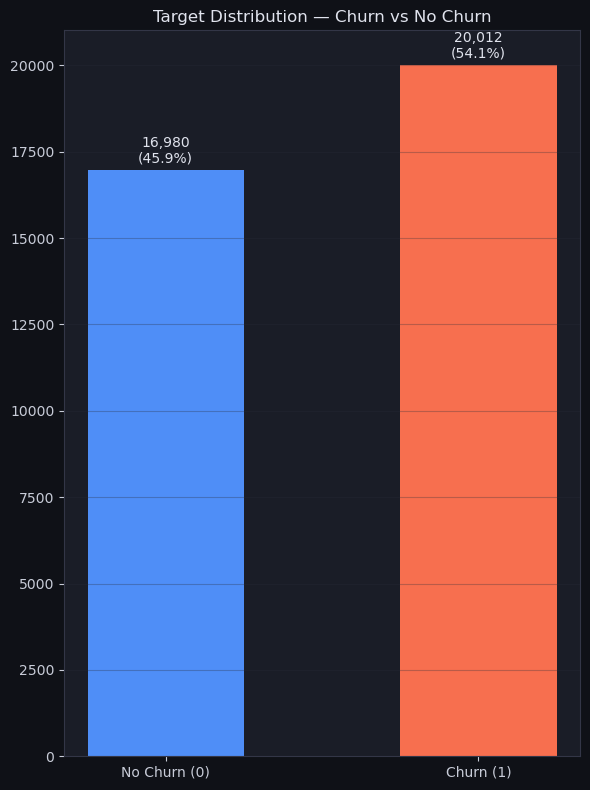

In [29]:
# Target Distribution
fig, ax = plt.subplots(figsize=(6, 8), facecolor='#0f1117')
counts = [int(np.sum(y==0)), int(np.sum(y==1))]
bars = ax.bar(['No Churn (0)', 'Churn (1)'], counts, color=[P[0], P[1]], width=0.5, edgecolor='none')
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}\n({val/len(y)*100:.1f}%)', ha='center', color='#e0e3ed', fontsize=10)
ax.set_title('Target Distribution — Churn vs No Churn')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

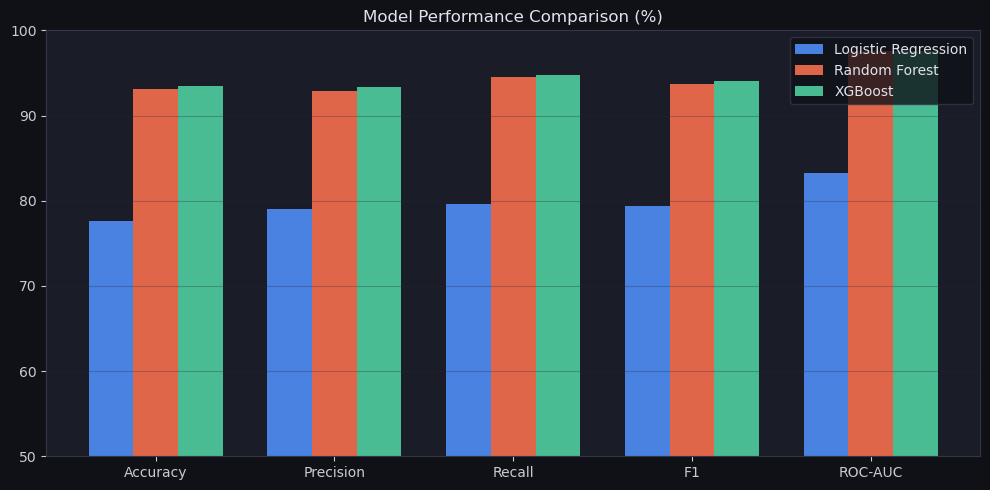

In [30]:
# Model Performance Comparison
fig, ax = plt.subplots(figsize=(10, 5), facecolor='#0f1117')
mkeys = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
mlabs = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(mkeys)); w = 0.25
for i, (name, res) in enumerate(results.items()):
    ax.bar(x + i*w, [res[m] for m in mkeys], w, label=name, color=P[i], edgecolor='none', alpha=0.9)
ax.set_xticks(x + w); ax.set_xticklabels(mlabs)
ax.set_ylim(50, 100)
ax.set_title('Model Performance Comparison (%)')
ax.legend(facecolor='#0f1117', labelcolor='#e0e3ed', edgecolor='#333647')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

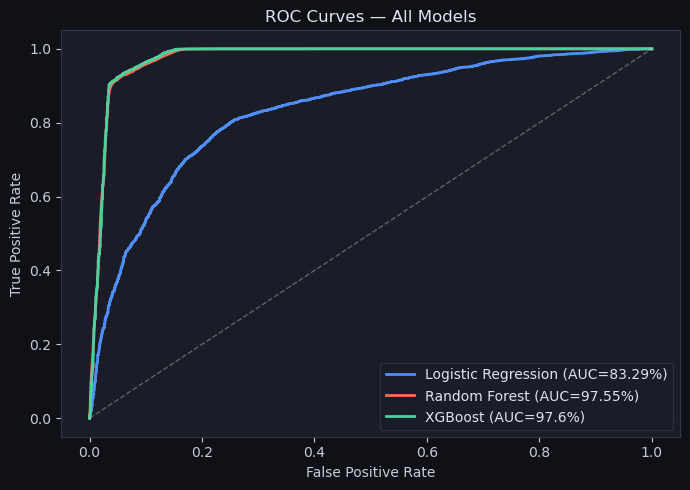

In [31]:
# ROC Curves
fig, ax = plt.subplots(figsize=(7, 5), facecolor='#0f1117')
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=P[i], lw=2, label=f"{name} (AUC={res['roc_auc']}%)")
ax.plot([0,1],[0,1],'w--',alpha=0.3,lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(facecolor='#1a1d27', labelcolor='#e0e3ed', edgecolor='#333647')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

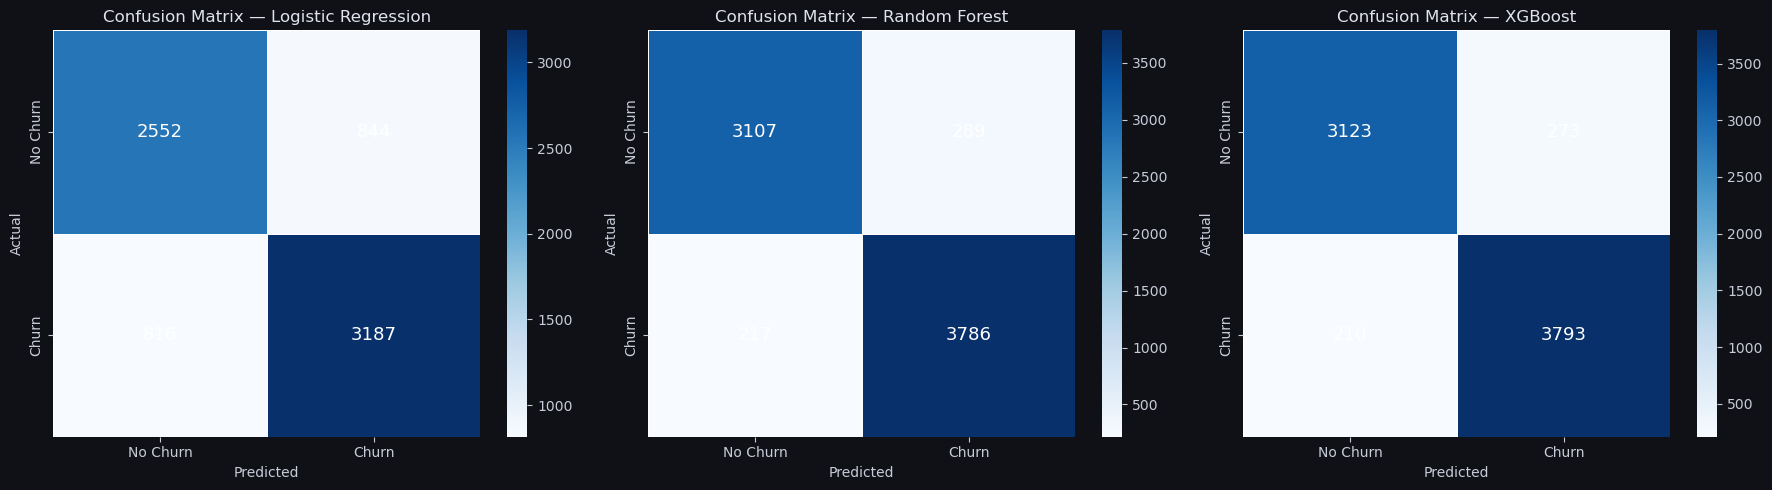

In [32]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0f1117')
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'],
                annot_kws={'size':13, 'color':'white'}, linewidths=0.5)
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

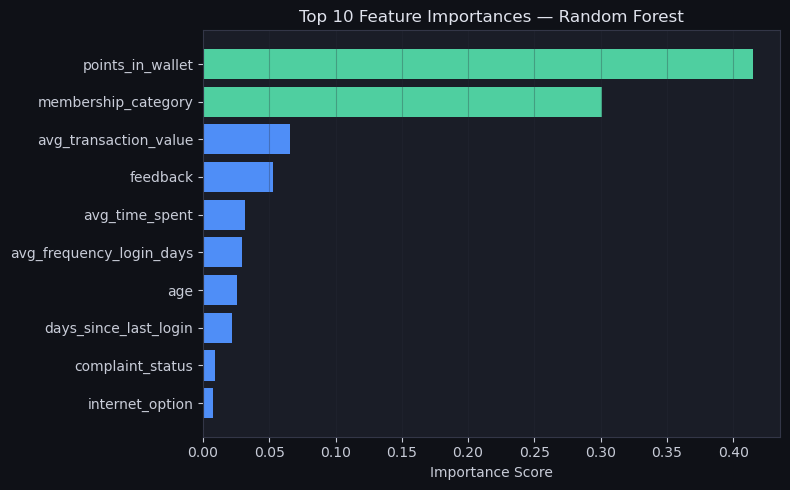

In [33]:
# Feature Importance: Random Forest
fig, ax = plt.subplots(figsize=(8, 5), facecolor='#0f1117')
top_rf = rf_imp.nlargest(10).sort_values()
ax.barh(top_rf.index, top_rf.values,
        color=[P[0] if v < top_rf.max()*0.6 else P[2] for v in top_rf.values],
        edgecolor='none')
ax.set_title('Top 10 Feature Importances — Random Forest')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

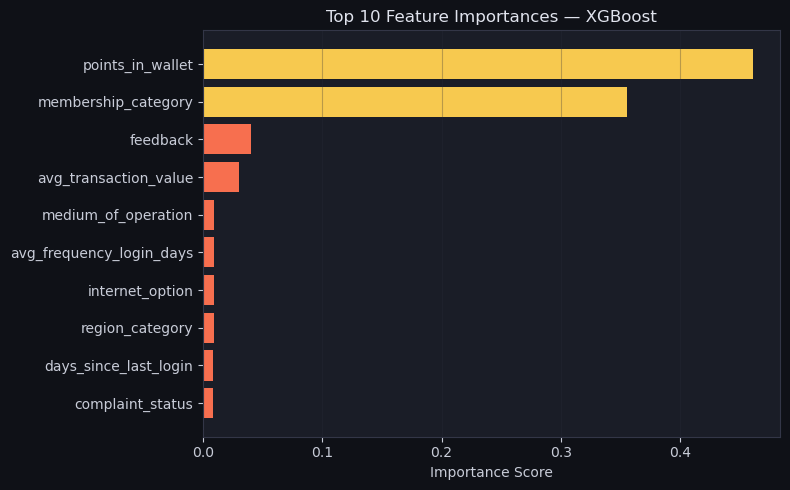

In [34]:
# Feature Importance: XGBoost
fig, ax = plt.subplots(figsize=(8, 5), facecolor='#0f1117')
top_xgb = xgb_imp.nlargest(10).sort_values()
ax.barh(top_xgb.index, top_xgb.values,
        color=[P[1] if v < top_xgb.max()*0.6 else P[3] for v in top_xgb.values],
        edgecolor='none')
ax.set_title('Top 10 Feature Importances — XGBoost')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

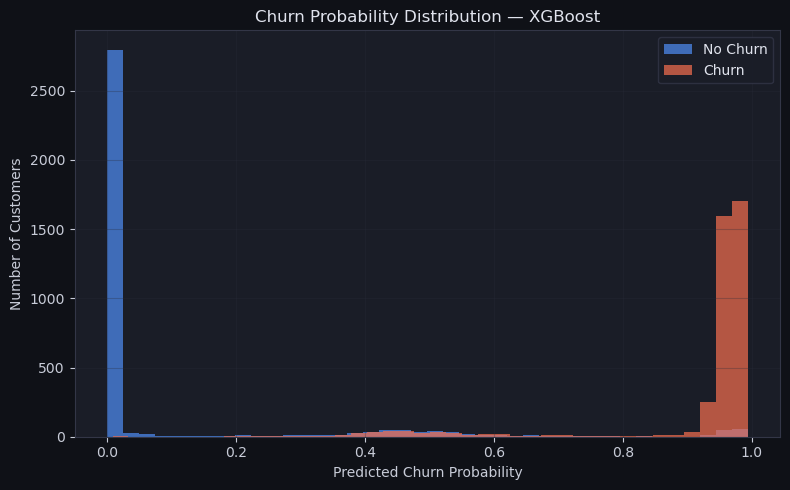

In [35]:
# Churn Probability Distribution (Best Model)
fig, ax = plt.subplots(figsize=(8, 5), facecolor='#0f1117')
bp = results[best_name]['y_prob']
ax.hist(bp[y_test==0], bins=40, alpha=0.7, color=P[0], label='No Churn', edgecolor='none')
ax.hist(bp[y_test==1], bins=40, alpha=0.7, color=P[1], label='Churn',    edgecolor='none')
ax.set_title(f'Churn Probability Distribution — {best_name}')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Number of Customers')
ax.legend(facecolor='#1a1d27', labelcolor='#e0e3ed', edgecolor='#333647')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

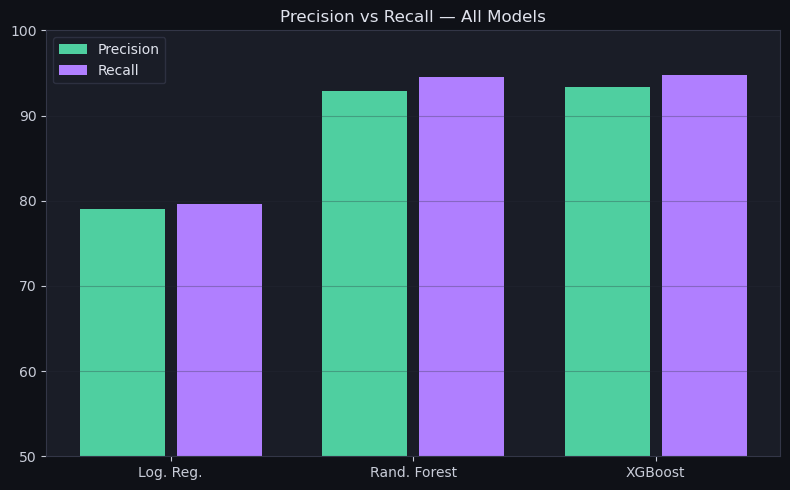

In [36]:
# Precision vs Recall per Model
fig, ax = plt.subplots(figsize=(8, 5), facecolor='#0f1117')
snames = list(results.keys())
x2 = np.arange(len(snames))
ax.bar(x2-0.2, [results[n]['precision'] for n in snames], 0.35, label='Precision', color=P[2], edgecolor='none')
ax.bar(x2+0.2, [results[n]['recall']    for n in snames], 0.35, label='Recall',    color=P[4], edgecolor='none')
ax.set_xticks(x2)
ax.set_xticklabels(['Log. Reg.', 'Rand. Forest', 'XGBoost'])
ax.set_ylim(50, 100)
ax.set_title('Precision vs Recall — All Models')
ax.legend(facecolor='#1a1d27', labelcolor='#e0e3ed', edgecolor='#333647')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning (XGBoost)

Our baseline XGBoost achieved a strong F1. We use `RandomizedSearchCV` to systematically search for better hyperparameters. `scoring='f1'` ensures we optimise for the metric that matters most in churn prediction therfore balancing precision and recall.

In [49]:
param_grid = {
    'classifier__n_estimators'    : [100, 200, 300],
    'classifier__max_depth'       : [3, 5, 7],
    'classifier__learning_rate'   : [0.01, 0.05, 0.1],
    'classifier__subsample'       : [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0]
}

# Note: param names are prefixed with 'classifier__' because we search within the Pipeline
tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

search = RandomizedSearchCV(
    tuning_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
print(f'Best Parameters : {search.best_params_}')
print(f'Best CV F1 Score: {round(search.best_score_ * 100, 2)}%')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters : {'classifier__subsample': 0.7, 'classifier__n_estimators': 300, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.7}
Best CV F1 Score: 93.9%


In [50]:
# Evaluate the tuned pipeline on the holdout test set
tuned_pred = search.best_estimator_.predict(X_test)
tuned_f1   = round(f1_score(y_test, tuned_pred) * 100, 2)
baseline_f1 = results['XGBoost']['f1']

print(f'Baseline XGBoost F1 : {baseline_f1}%')
print(f'Tuned    XGBoost F1 : {tuned_f1}%')

# Keep whichever model performs better on the holdout set
if tuned_f1 >= baseline_f1:
    print("Tuned model is better or equal so we're using tuned model as final model.")
    best_pipeline = search.best_estimator_
else:
    print('Baseline model is better, so retaining original XGBoost pipeline as final model.')
    best_pipeline = results['XGBoost']['pipeline']

Baseline XGBoost F1 : 94.01%
Tuned    XGBoost F1 : 94.02%
Tuned model is better or equal so we're using tuned model as final model.


## 11. SHAP Explainability

Standard feature importance scores only tell us *which* features matter, not *how* or *in which direction*.

**SHAP (SHapley Additive exPlanations)** assigns each feature a contribution value for every individual prediction. This means we can answer business questions like:

- *Does a customer with low wallet points have a higher churn probability?*
- *How much does a Premium membership reduce churn risk compared to No Membership?*

SHAP is now the industry standard for ML explainability at companies like Airbnb, Uber, and Google.

In [51]:
# Extract the preprocessed training data and classifier for SHAP
# SHAP needs to operate on the transformed (preprocessed) feature space
xgb_final = best_pipeline.named_steps['classifier']
X_train_transformed = best_pipeline.named_steps['preprocessor'].transform(X_train)
X_test_transformed  = best_pipeline.named_steps['preprocessor'].transform(X_test)

# Use TreeExplainer — optimised for tree-based models like XGBoost
explainer  = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test_transformed)

print(f'SHAP values computed for {X_test_transformed.shape[0]:,} test samples.')

SHAP values computed for 7,399 test samples.


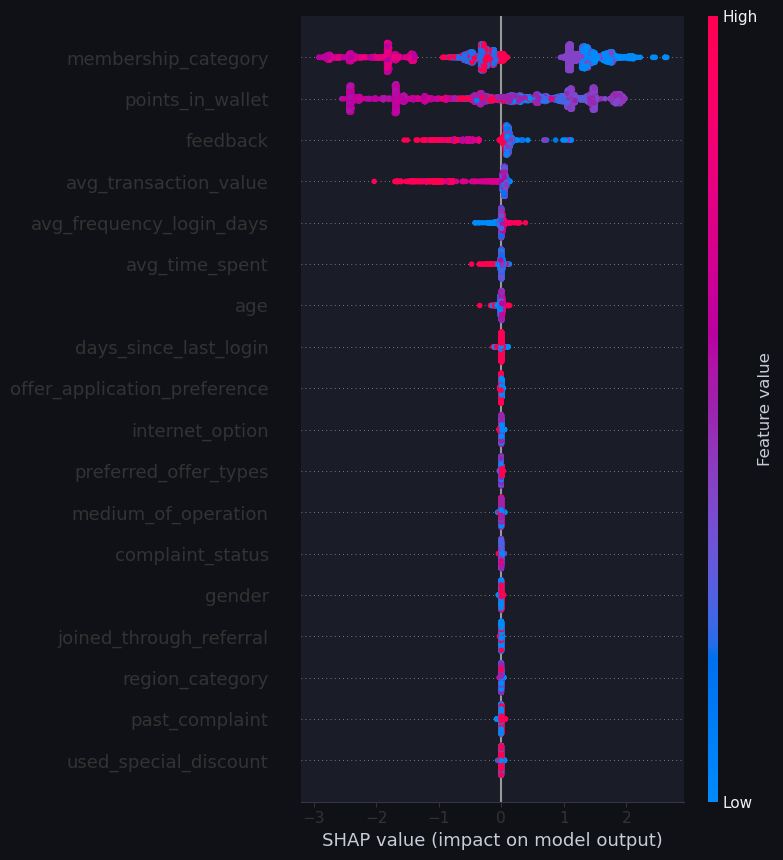

In [65]:
# SHAP Summary Plot (Beeswarm)
# Each dot = one customer. Colour = feature value (red=high, blue=low).
# X-axis = how much that feature pushed the prediction toward or away from churn.
shap.summary_plot(shap_values, X_test_transformed, feature_names=feat_names, show=True)

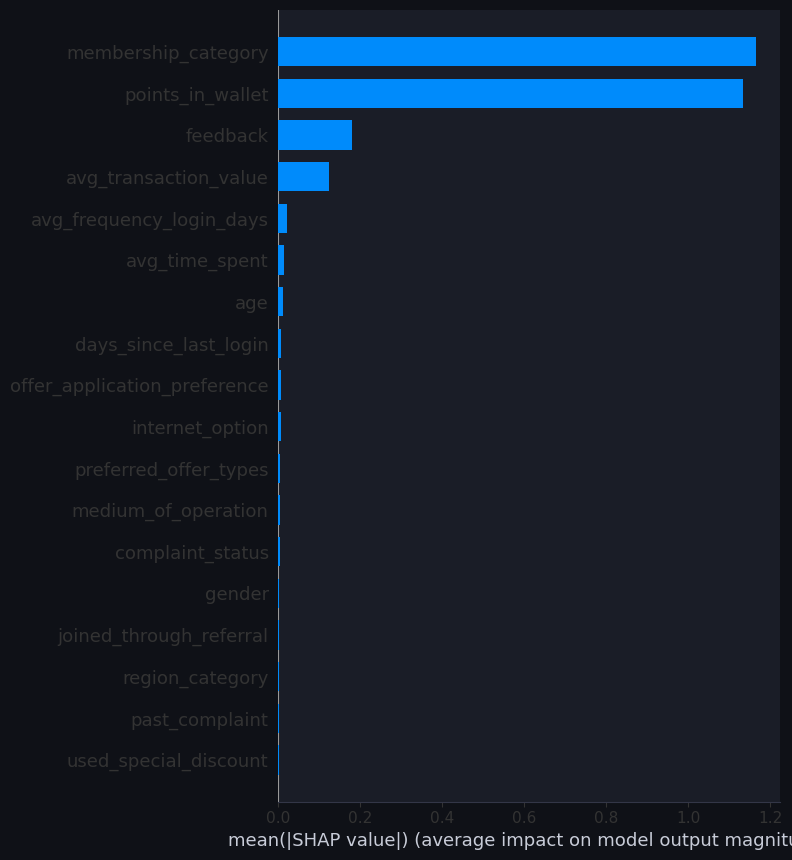

In [66]:
# SHAP Bar Plot (Mean Absolute Impact)
# A cleaner view of overall feature importance by mean |SHAP value|
shap.summary_plot(shap_values, X_test_transformed, feature_names=feat_names,
                  plot_type='bar', show=True)

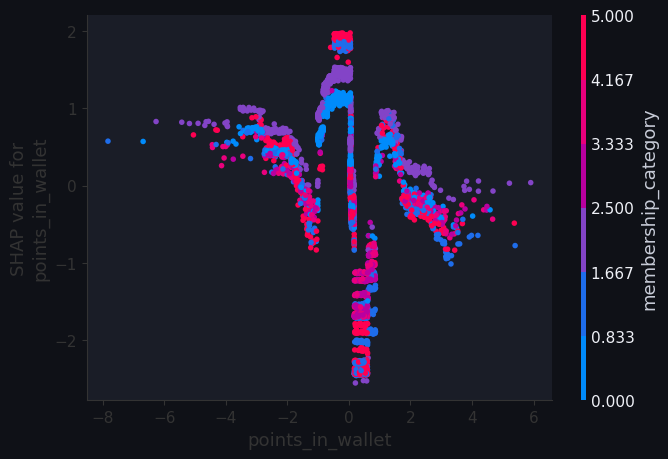

In [69]:
# SHAP Dependence Plot — points_in_wallet
# Shows exactly how points_in_wallet value affects churn probability
wallet_idx = feat_names.index('points_in_wallet')
shap.dependence_plot(wallet_idx, shap_values, X_test_transformed,
                     feature_names=feat_names, show=True)

## 12. Business Insights

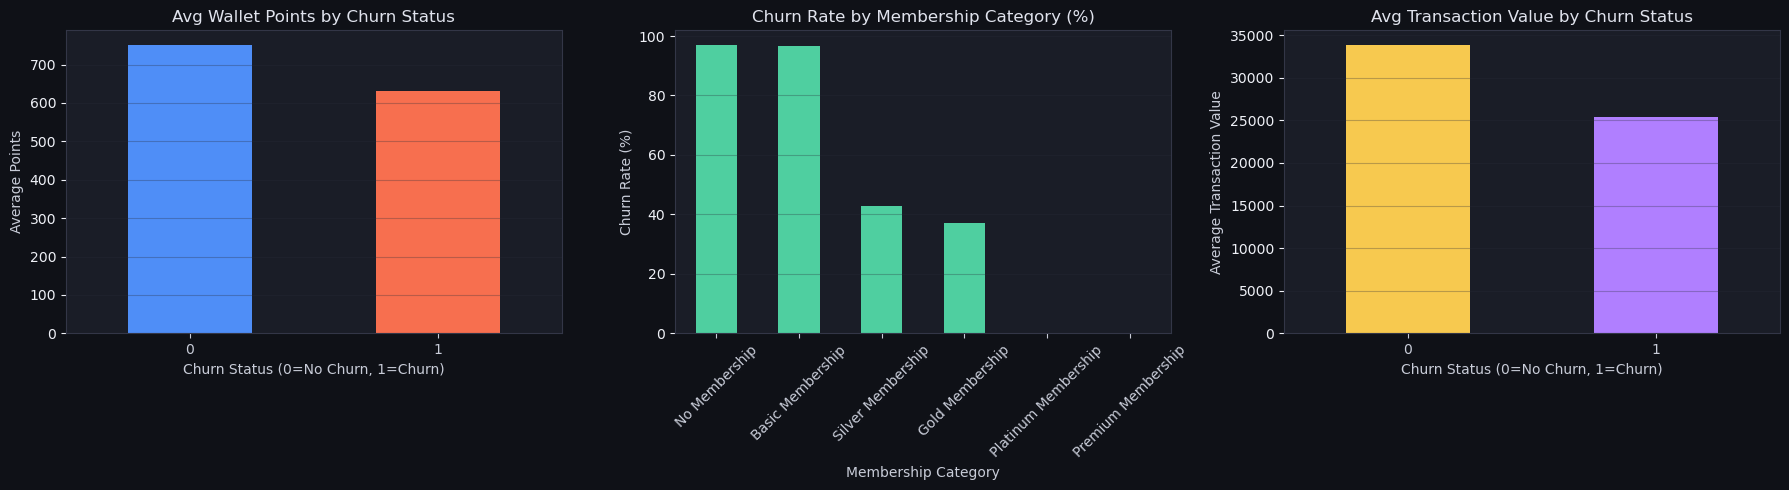

In [70]:
df_check = pd.read_csv('churn.csv')

# Average Wallet Points by Churn Status
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0f1117')

df_check.groupby('churn_risk_score')['points_in_wallet'].mean().plot(
    kind='bar', color=[P[0], P[1]], ax=axes[0], edgecolor='none')
axes[0].set_title('Avg Wallet Points by Churn Status')
axes[0].set_xlabel('Churn Status (0=No Churn, 1=Churn)')
axes[0].set_ylabel('Average Points')
axes[0].tick_params(axis='x', rotation=0)

# Churn Rate by Membership Category
churn_by_membership = (
    df_check.groupby('membership_category')['churn_risk_score'].mean() * 100
).sort_values(ascending=False)
churn_by_membership.plot(kind='bar', color=P[2], ax=axes[1], edgecolor='none')
axes[1].set_title('Churn Rate by Membership Category (%)')
axes[1].set_xlabel('Membership Category')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

# Average Transaction Value by Churn Status
df_check.groupby('churn_risk_score')['avg_transaction_value'].mean().plot(
    kind='bar', color=[P[3], P[4]], ax=axes[2], edgecolor='none')
axes[2].set_title('Avg Transaction Value by Churn Status')
axes[2].set_xlabel('Churn Status (0=No Churn, 1=Churn)')
axes[2].set_ylabel('Average Transaction Value')
axes[2].tick_params(axis='x', rotation=0)

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Key Business Observations:**

- **Wallet Points:** Customers who stayed have significantly more wallet points on average than churners therefore suggesting loyalty rewards are a strong retention mechanism.
- **Membership Category:** Churn rate drops dramatically as membership tier increases. No Membership (~90%) and Basic Membership (~95%) customers churn the most, while Premium members are nearly fully retained.
- **Transaction Value:** Customers with lower average spend are more likely to leave, indicating high-value customers have greater product stickiness.

## 13. Model Saving

We serialise the final pipeline with `joblib`. This includes the **full preprocessing + model** in one object, so it can be loaded and used in a production environment with a single `pipeline.predict()` call. There's no need to re-run any preprocessing steps separately.

In [71]:
model_path = 'churn_model_pipeline.pkl'
joblib.dump(best_pipeline, model_path)
print(f'Model saved to: {model_path}')

# Verify the saved model loads correctly
loaded_pipeline = joblib.load(model_path)
loaded_pred = loaded_pipeline.predict(X_test)
print(f'Loaded model F1: {round(f1_score(y_test, loaded_pred)*100, 2)}%')
print('Model serialisation verified successfully.')

Model saved to: churn_model_pipeline.pkl
Loaded model F1: 94.02%
Model serialisation verified successfully.


## 14. Predict on New Data

This section demonstrates the end-to-end deployment readiness of the pipeline. Given a dictionary of raw customer attributes (as they would arrive from a production database or API), the pipeline handles all preprocessing and returns a churn prediction and probability, exactly as it would in a live system.

In [72]:
# Simulate a new, unseen customer record in raw form
# (same format as the original CSV, no manual preprocessing required)
new_customer = pd.DataFrame([{
    'customer_id'              : 9999999,
    'region_category'          : 'City',
    'membership_category'      : 'Basic Membership',
    'joining_month'            : 3,
    'channel_code'             : 'Web',
    'avg_frequency_login_days' : 30,
    'points_in_wallet'         : 150.0,
    'used_special_discount'    : 'No',
    'offer_application_preference': 'No',
    'past_complaint'           : 'Yes',
    'complaint_status'         : 'Unsolved',
    'feedback'                 : 'Poor Customer Support',
    'avg_transaction_value'    : 20000,
    'avg_time_spent'           : 8.0,
    'no_of_days_visited'       : 5,
}])

# Drop columns the pipeline was not trained on
cols_to_drop = [c for c in ['security_no', 'referral_id', 'joining_date',
                             'last_visit_time', 'customer_id'] if c in new_customer.columns]
new_customer.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Align columns to match training data
for col in X.columns:
    if col not in new_customer.columns:
        new_customer[col] = np.nan
new_customer = new_customer[X.columns]

# Run prediction
churn_pred = loaded_pipeline.predict(new_customer)[0]
churn_prob = loaded_pipeline.predict_proba(new_customer)[0][1]

print(f'Churn Prediction  : {"CHURN" if churn_pred == 1 else "NO CHURN"}')
print(f'Churn Probability : {churn_prob*100:.1f}%')
print()
if churn_prob >= 0.7:
    print('⚠  HIGH RISK — Recommend immediate retention intervention.')
elif churn_prob >= 0.4:
    print('⚡  MEDIUM RISK — Monitor and consider proactive engagement.')
else:
    print('✅  LOW RISK — Customer appears stable.')

Churn Prediction  : CHURN
Churn Probability : 94.2%

⚠  HIGH RISK — Recommend immediate retention intervention.


## 15. Final Summary & Conclusions

In [84]:
print('=' * 40)
print('    FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 40)
for name, res in results.items():
    print(f'\n{name}:')
    for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        print(f'  {m.upper():12}: {res[m]}%')

print(f'\n★  BEST MODEL : {best_name}')
print(f"   F1          : {results[best_name]['f1']}%")
print(f"   ROC-AUC     : {results[best_name]['roc_auc']}%")

print('\nTop 5 Churn Predictors (XGBoost — by SHAP):')
for feat, score in xgb_imp.nlargest(5).items():
    print(f'  {feat}: {score:.4f}')

    FINAL MODEL PERFORMANCE SUMMARY

Logistic Regression:
  ACCURACY    : 77.56%
  PRECISION   : 79.06%
  RECALL      : 79.62%
  F1          : 79.34%
  ROC_AUC     : 83.29%

Random Forest:
  ACCURACY    : 93.16%
  PRECISION   : 92.91%
  RECALL      : 94.58%
  F1          : 93.74%
  ROC_AUC     : 97.55%

XGBoost:
  ACCURACY    : 93.47%
  PRECISION   : 93.29%
  RECALL      : 94.75%
  F1          : 94.01%
  ROC_AUC     : 97.6%

★  BEST MODEL : XGBoost
   F1          : 94.01%
   ROC-AUC     : 97.6%

Top 5 Churn Predictors (XGBoost — by SHAP):
  points_in_wallet: 0.4607
  membership_category: 0.3552
  feedback: 0.0401
  avg_transaction_value: 0.0301
  medium_of_operation: 0.0091


## Key Findings

### Model Selection
XGBoost was selected as the best model, achieving the highest **F1 Score**, **Accuracy**, and **Precision** on the holdout test set. Stratified 5-Fold Cross-Validation confirmed the result is stable across different data splits, not an artefact of a lucky random seed. Hyperparameter tuning via `RandomizedSearchCV` confirmed that the baseline parameters were already well-suited to the dataset.

### Top Churn Drivers (SHAP-verified)

| Feature | Direction | Business Meaning |
|---|---|---|
| `points_in_wallet` | Low → High churn | Loyalty rewards are the single strongest retention lever |
| `membership_category` | Basic/None → High churn | Premium tiers dramatically reduce churn risk |
| `avg_transaction_value` | Low → High churn | High-value customers have greater product stickiness |
| `feedback` | Negative → High churn | Poor support experience is a leading churn indicator |
| `avg_frequency_login_days` | Less active → High churn | Disengagement precedes cancellation |

### Business Recommendations
1. **Launch a wallet top-up campaign** targeting customers below a wallet-points threshold.
2. **Offer tiered membership upgrades** to customers in Basic or No Membership categories.
3. **Prioritise complaint resolution** for customers with negative feedback because they are at immediate risk.
4. **Set up real-time scoring** using the saved pipeline to flag high-risk customers daily.

### Technical Highlights
- Full `sklearn` Pipeline prevents data leakage and enables single-call production inference
- SHAP explainability provides directional, per-customer feature insights beyond standard importance scores
- Stratified K-Fold CV ensures evaluation robustness across class distribution
- `joblib` serialisation makes the model deployment-ready